In [105]:
#PROJET METHODES NUMERIQUES POUR LE PRICING D'OPTION  :OPTION ASIATIQUE 

In [106]:
# Téléchargement des librairies 

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from time import perf_counter


In [107]:
#Paramètres

r = 0.05 # taux sans risque 
q = 0.02 # taux de dividende 
sigma = 0.1 # volatilité
dt = 1/270 # pas de temps (en années)
S0 = 100 # prix initial de l'actif
T = 5 # échéance
nt = int(T/dt) # nombre de pas de temps (attention au type int)
K = 115 # strike
nMC = 1000# nb de simulations Monte-Carlo

In [108]:
# Fonction pour simuler UNE trajectoire de l'actif et calculer le pay-off de l'option asiatique (pour un CALL)
def Payoff_asiatique_call(S0, r,q, sigma, K, dt, nt):
    somme_Sn = 0  # On va sommer les prix pour en faire la moyenne, donc au début somme = 0 
    S = S0 #On démarre à S0 le prix d'entrée (définit dans les paramètres)
    S_valeurs = np.zeros(nt + 1) # On crée un vecteur nul qui nous servira à stocker les valeurs de tous les prix calculés dans la boucle
    S_valeurs[0] = S0 #Première valeur du vecteur prix 
 

    for i in range(nt):
        dW = np.random.normal(0, np.sqrt(dt)) #On génère un mouvement Brownien à chaque itération
        S = S * np.exp((r -q - 0.5 * sigma**2) * dt + sigma * dW) # Formule de BS
        somme_Sn += S # On ajoute le nouveau prix calculé à la somme 
        S_valeurs[i + 1] = S # On stock le nouveau prix dans le vecteur 
    
    moyenne = somme_Sn / nt # On fait la moyenne de tous nos prix (option asiatique)
    payoff = max(moyenne - K, 0) # On calcule le payoff : içi c'est la cas d'un call 
    
    print("Le payoff simulé pour cette trajectoire est : " + str(round(payoff, 4))) #renvoi le payoff(ce qui nous interesse principalement, arrondi 4 chiffres après la virgule)
    print("Moyenne des prix simulés :", moyenne)
    return payoff, moyenne, S_valeurs # Renvoi le payoff , la moyenne et le vecteur prix 


In [109]:
#Test fonction CALL

Payoff_asiatique_call(110,0.08 ,0.02, 0.05, 115, 1/270, 1350)


Le payoff simulé pour cette trajectoire est : 11.1733
Moyenne des prix simulés : 126.17331711577418


(11.173317115774182,
 126.17331711577418,
 array([110.        , 109.59725458, 109.76676429, ..., 139.7723786 ,
        139.88396419, 139.55441979]))

Le payoff simulé pour cette trajectoire est : 23.426
Moyenne des prix simulés : 138.42603935627253


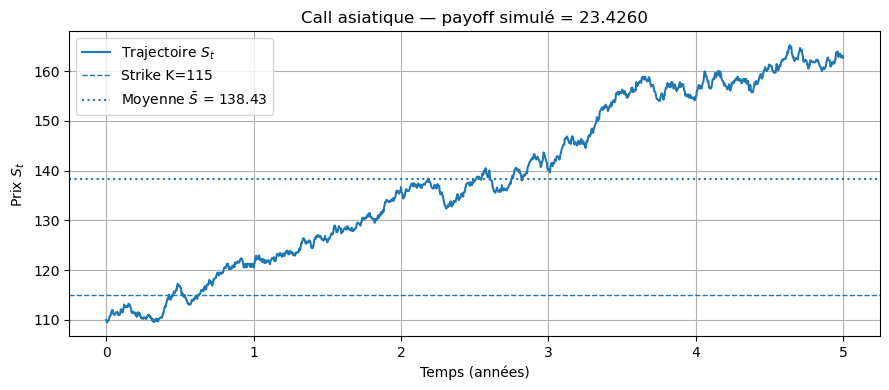

In [110]:
#Test fonction CALL : représentation graphique :


#Appel de la fonction 
payoff, moyenne, S_valeurs = Payoff_asiatique_call(110, 0.06, 0.02, 0.05, 115, 1/270, 1350)

#Paramètres pour cette exemple : 

dt = 1/270
nt = 1350
T = nt * dt
t = np.linspace(0, T, nt + 1)

# Représentation graphique 
plt.figure(figsize=(9,4))
plt.plot(t, S_valeurs, linewidth=1.5, label="Trajectoire $S_t$")
plt.axhline(115, linestyle="--", linewidth=1, label="Strike K=115")
plt.axhline(moyenne, linestyle=":", linewidth=1.5, label=f"Moyenne $\\bar S$ = {moyenne:.2f}")

plt.title(f"Call asiatique — payoff simulé = {payoff:.4f}")
plt.xlabel("Temps (années)")
plt.ylabel("Prix $S_t$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [111]:
# Fonction pour simuler UNE trajectoire de l'actif et calculer le pay-off de l'option asiatique (pour un PUT)
def Payoff_asiatique_put(S0, r,q, sigma, K, dt, nt):
    somme_Sn = 0  # On va sommer les prix pour en faire la moyenne, donc au début somme = 0 
    S = S0 #On démarre à S0 le prix d'entrée (définit dans les paramètres)
    S_valeurs = np.zeros(nt + 1) # On crée un vecteur nul qui nous servira à stocker les valeurs de tous les prix calculés dans la boucle
    S_valeurs[0] = S0 #Première valeur du vecteur prix 
 

    for i in range(nt):
        dW = np.random.normal(0, np.sqrt(dt)) #On génère un mouvement Brownien à chaque itération
        S = S * np.exp((r -q - 0.5 * sigma**2) * dt + sigma * dW) # Formule de BS
        somme_Sn += S # On ajoute le nouveau prix calculé à la somme 
        S_valeurs[i + 1] = S # On stock le nouveau prix dans le vecteur 
    
    moyenne = somme_Sn / nt # On fait la moyenne de tous nos prix (option asiatique)
    payoff = max(K-moyenne, 0) # On calcule le payoff : içi c'est la cas d'un put 
    
    print("Le payoff simulé pour cette trajectoire est : " + str(round(payoff, 4))) #renvoi le payoff(ce qui nous interesse principalement, arrondi 4 chiffres après la virgule)
    print("Moyenne des prix simulés :", moyenne)
    return payoff, moyenne, S_valeurs # Renvoi le payoff , la moyenne et le vecteur prix 

In [112]:
#Test fonction PUT

Payoff_asiatique_put(90,0.02 ,0.02, 0.05, 98 , 1/270, 1350)

Le payoff simulé pour cette trajectoire est : 13.3773
Moyenne des prix simulés : 84.62271575384767


(13.377284246152328,
 84.62271575384767,
 array([90.        , 90.14925969, 89.74080281, ..., 79.34034759,
        79.36151477, 79.77363474]))

Le payoff simulé pour cette trajectoire est : 0
Moyenne des prix simulés : 101.58053104458884


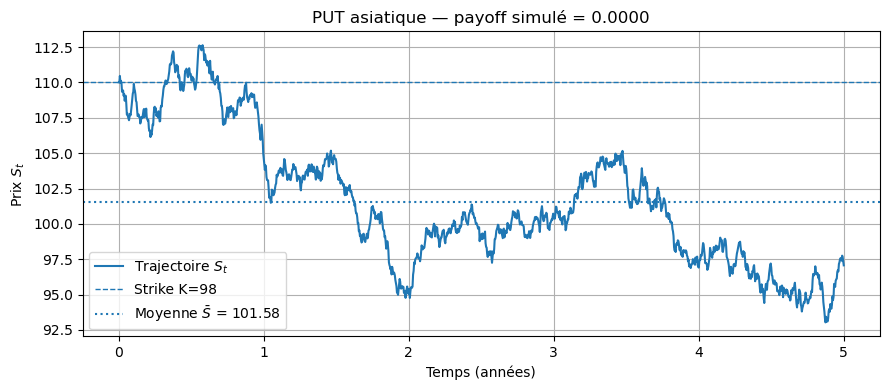

In [113]:
#Test fonction PUT : représentation graphique :


#Appel de la fonction 
payoff, moyenne, S_valeurs = Payoff_asiatique_put(110,0.02 ,0.03, 0.05, 98 , 1/270, 1350)

#Paramètres pour cette exemple : 

dt = 1/270
nt = 1350
T = nt * dt
t = np.linspace(0, T, nt + 1)

# Représentation graphique 
plt.figure(figsize=(9,4))
plt.plot(t, S_valeurs, linewidth=1.5, label="Trajectoire $S_t$")
plt.axhline(110, linestyle="--", linewidth=1, label="Strike K=98")
plt.axhline(moyenne, linestyle=":", linewidth=1.5, label=f"Moyenne $\\bar S$ = {moyenne:.2f}")

plt.title(f"PUT asiatique — payoff simulé = {payoff:.4f}")
plt.xlabel("Temps (années)")
plt.ylabel("Prix $S_t$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [115]:
#Simulation Monte Carlo

S = np.zeros((nt+1,nMC)) #Matrice de zéros 
S[0,:] = S0 #Prix de départ 
for i in range(nt): 
    S[i+1,:] = S[i,:] + (r-q)*S[i,:]*dt + sigma*S[i,:]*np.random.normal(0,np.sqrt(dt),nMC) # formule de BS
S



array([[100.        , 100.        , 100.        , ..., 100.        ,
        100.        , 100.        ],
       [100.49072592,  99.39510005,  99.57216752, ..., 100.5380758 ,
        100.29060909, 100.10692601],
       [100.08226523,  99.21551988,  99.7692541 , ..., 101.10622403,
        100.83136802, 100.70928831],
       ...,
       [107.6876181 ,  82.62431889, 125.01329338, ..., 160.52788709,
        161.97794473, 116.33191965],
       [107.31508264,  81.81548529, 125.73519789, ..., 161.43940143,
        160.98553913, 116.59807862],
       [106.40078123,  82.03447717, 124.77738842, ..., 159.83835815,
        162.394956  , 116.52816611]])

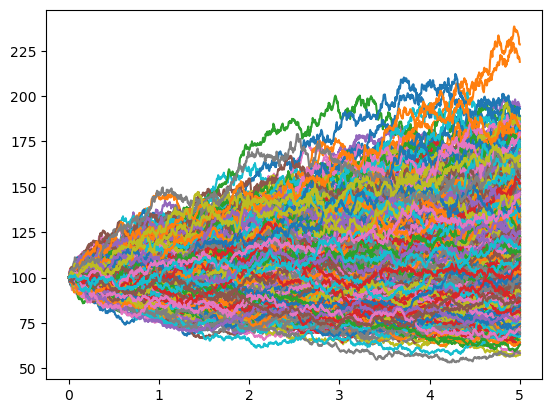

In [116]:
# plot de plein de simulation du prix de l'actif en fonction du temps
plt.plot(np.arange(nt+1)*dt,S)

In [117]:
#Estimation Monte Carlo du prix de l'option 

S_mean = S[1:, :].mean(axis=0) # On calcule la moyenne arithmétique des prix simulés pour chaque trajectoire
payoff = np.maximum(S_mean - K, 0.0) # Calcul du payoff
price_asian = np.exp(-r*T) * payoff.mean() # Actualisation de la moyenne des payoffs 
print("Prix estimé du call asiatique :", price_asian)

Prix estimé du call asiatique : 2.1617054870474064


In [118]:
#Fonction presque similaire à la précédente mais celle ci renvoi juste le payoff (utilisé
#après pour créer un vecteur de plusieurs payoffs)

def Payoff_asiatique_call2(S0, r,q, sigma, K, dt, nt):
    somme_Sn = 0  # On va sommer les prix pour en faire la moyenne, donc au début somme = 0 
    S = S0 #On démarre à S0 le prix d'entrée (définit dans les paramètres)
    S_valeurs = np.zeros(nt + 1) # On crée un vecteur nul qui nous servira à stocker les valeurs de tous les prix calculés dans la boucle
    S_valeurs[0] = S0 #Première valeur du vecteur prix 
 

    for i in range(nt):
        dW = np.random.normal(0, np.sqrt(dt)) #On génère un mouvement Brownien à chaque itération
        S = S * np.exp((r -q - 0.5 * sigma**2) * dt + sigma * dW) # Formule de BS
        somme_Sn += S # On ajoute le nouveau prix calculé à la somme 
        S_valeurs[i + 1] = S # On stock le nouveau prix dans le vecteur 
    
    moyenne = somme_Sn / nt # On fait la moyenne de tous nos prix (option asiatique)
    payoff = max(moyenne - K, 0) # On calcule le payoff : içi c'est la cas d'un call 
    

    return payoff # Renvoi le payoff , la moyenne et le vecteur prix 

In [119]:
#Calcul de l'intervalle de confiance 

payoffs = np.zeros (nMC) #création vecteur nul de taille nMC

for i in range (nMC) :
    payoffs [i] = Payoff_asiatique_call2(S0, r,q, sigma, K, dt, nt) # Calcul d'une série de payoff (CALL)

actu = np.exp(-r*T) #actualisation 
C0 = actu*payoffs.mean() #prix au temps t = 0 
SE = actu* payoffs.std(ddof=1) / np.sqrt(nMC) #estimation du prix moyen par la moyenne empirique 
z = 1.96
IC = (C0 - z*SE, C0 + z*SE) #intervalle de confiance 

print("Prix MC :", C0)
print("IC 95% :", IC)

Prix MC : 1.9668581785225085
IC 95% : (1.6819370645091096, 2.2517792925359075)


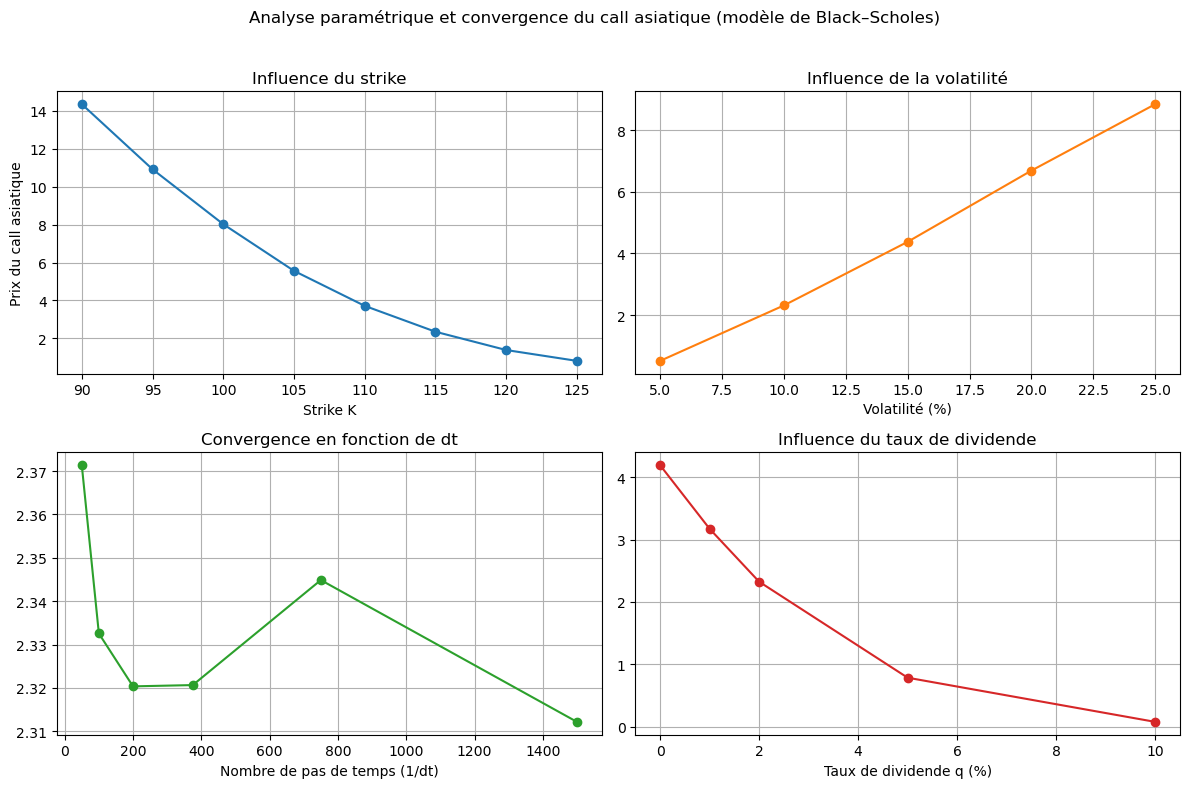

In [120]:
#Analyse paramètrique du prix du call en faisant varier les différents paramètres avec figure associé 


# Paramètres 

S0 = 100 # Prix initial 
r = 0.05 # taux sans risque
q = 0.02 # taux de dividende
sigma = 0.10 # volatilité
T = 5  # échéance (années)
nMC = 80000 # nombre de trajectoires
rng = np.random.default_rng(42)

# Fonction de pricing asiatique

def asian_call_price(S0, K, r, q, sigma, T, nMC, dt):
    nt = int(T/dt)
    drift = (r - q - 0.5*sigma**2)*dt #terme de dérive dans la formule excate 
    vol = sigma*np.sqrt(dt) #terme de volatilité dans la formule excate
    S = np.empty((nt+1, nMC)) #Matrice de prix simulés
    S[0,:] = S0
    for i in range(nt):
        Z = rng.standard_normal(nMC)
        S[i+1,:] = S[i,:] * np.exp(drift + vol*Z)
    S_mean = S[1:,:].mean(axis=0) #Moyenne arithmétique des prix
    payoff = np.maximum(S_mean - K, 0)
    return np.exp(-r*T)*payoff.mean() #espérance actualisé sur la mesure risque-neutre

# 1) Influence du Strike

K_values = np.arange(90, 130, 5) #différents niveax de strike 
price_K = [asian_call_price(S0, K, r, q, sigma, T, nMC, 1/375) for K in K_values]


# 2) Influence de la Volatilité

sigma_values = np.linspace(0.05, 0.25, 5) #différentes valeurs de volatilité
price_sigma = [asian_call_price(S0, 115, r, q, s, T, nMC, 1/375) for s in sigma_values]


# 3) Influence du pas de temps dt (convergence)

dt_values = [1/50, 1/100, 1/200, 1/375, 1/750, 1/1500]  # Test de pas de temps grossier
price_dt = [asian_call_price(S0, 115, r, q, sigma, T, nMC, dt) for dt in dt_values]


# 4) Influence du taux de dividende q

q_values = np.array([0.0, 0.01, 0.02, 0.05, 0.10])
price_q = [asian_call_price(S0, 115, r, qv, sigma, T, nMC, 1/375) for qv in q_values]


# Figure combinée (4 sous-graphiques)

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# (1) Strike
axs[0,0].plot(K_values, price_K, 'o-', color='tab:blue')
axs[0,0].set_xlabel('Strike K')
axs[0,0].set_ylabel('Prix du call asiatique')
axs[0,0].set_title('Influence du strike')
axs[0,0].grid(True)

# (2) Volatilité
axs[0,1].plot(sigma_values*100, price_sigma, 'o-', color='tab:orange')
axs[0,1].set_xlabel('Volatilité (%)')
axs[0,1].set_title('Influence de la volatilité')
axs[0,1].grid(True)

# (3) Pas de temps dt
axs[1,0].plot(1/np.array(dt_values), price_dt, 'o-', color='tab:green')
axs[1,0].set_xlabel('Nombre de pas de temps (1/dt)')
axs[1,0].set_title('Convergence en fonction de dt')
axs[1,0].grid(True)

# (4) Dividende q
axs[1,1].plot(q_values*100, price_q, 'o-', color='tab:red')
axs[1,1].set_xlabel('Taux de dividende q (%)')
axs[1,1].set_title('Influence du taux de dividende')
axs[1,1].grid(True)

plt.suptitle("Analyse paramétrique et convergence du call asiatique (modèle de Black–Scholes)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [121]:
#Simulation Monte Carlo avec dees stats 

def asian_call_euler_once(S0, K, r, q, sigma, T, dt, nMC, seed=0):
    rng = np.random.default_rng(seed)
    nt = int(T/dt)
    # boucle en temps (Euler-Maruyama)
    S = np.zeros((nt+1, nMC))
    S[0,:] = S0
    t0 = perf_counter() #départ du chrono 
    for i in range(nt):
        Z = rng.standard_normal(nMC)
        S[i+1,:] = S[i,:] + (r-q)*S[i,:]*dt + sigma*S[i,:]*np.sqrt(dt)*Z

    # payoff et prix
    S_mean = S[1:, :].mean(axis=0) # moyenne arithmétique par trajectoire
    payoff  = np.maximum(S_mean - K, 0.0)
    disc    = np.exp(-r*T) #facteur d'actualisation
    X       = disc * payoff # prix par trajectoire
    price   = float(X.mean()) #prix estimé (Monte carlo)
    SE      = float(X.std(ddof=1) / np.sqrt(nMC))   # erreur standard de l'estimateur MC
    t1 = perf_counter() #fin chrono
    time_s  = t1 - t0
    return {"price": price, "SE": SE, "time_s": time_s,
            "paths": nMC, "paths_per_s": nMC/max(time_s,1e-12),
            "eff": time_s*(SE**2)} # trajectoires simulées par seconde ; test d'éfficacité ( critère temps * variance)

# Benchmarks (On fait varier nMC avec dt fixé)
# On étudie l'effet du nombre de trajectoires nMC sur : le prix estimé, l'erreur standard et le temps de calcul.

def bench_scaling_nmc(S0=100, K=115, r=0.05, q=0.02, sigma=0.1, T=5,
                      dt=1/360, n_list=(5_000, 20_000, 80_000, 320_000), seed=123):
    print("\n=== Scaling en nMC (dt fixe) ===")
    print("nMC       price     SE        time(s)  paths/s    Eff(time*SE^2)")
    for n in n_list:
        out = asian_call_euler_once(S0,K,r,q,sigma,T,dt,n,seed=seed)
        print(f"{n:8d}  {out['price']:.5f}  {out['SE']:.5f}  {out['time_s']:.2f}   "
              f"{out['paths_per_s']:.0f}     {out['eff']:.2e}")
        
# Benchmarks (On fait varier dt avec nMC fixé)
# On étudie l'effet du pas de temps dt sur : le prix estimé, l'erreur standard et le temps de calcul.

def bench_scaling_dt(S0=100, K=115, r=0.05, q=0.02, sigma=0.1, T=5,
                     nMC=80_000, dt_list=(1/50,1/100,1/200,1/360,1/750,1/1500), seed=321):
    print("\n=== Scaling en dt (nMC fixe) ===")
    print("1/dt     price     SE        time(s)  paths/s    Eff(time*SE^2)")
    for dt in dt_list:
        out = asian_call_euler_once(S0,K,r,q,sigma,T,dt,nMC,seed=seed)
        print(f"{int(1/dt):7d}  {out['price']:.5f}  {out['SE']:.5f}  {out['time_s']:.2f}   "
              f"{out['paths_per_s']:.0f}     {out['eff']:.2e}")


# Tests avec les paramètres 

r = 0.05
q = 0.02
sigma = 0.1
dt = 1/360
S0 = 100
T = 5
K = 115


bench_scaling_nmc(S0,K,r,q,sigma,T,dt, n_list=(5_000, 20_000, 80_000, 320_000), seed=7)
bench_scaling_dt(S0,K,r,q,sigma,T, nMC=80_000,
                 dt_list=(1/50,1/100,1/200,1/360,1/750,1/1500), seed=11)


=== Scaling en nMC (dt fixe) ===
nMC       price     SE        time(s)  paths/s    Eff(time*SE^2)
    5000  2.34440  0.07523  0.14   35241     8.03e-04
   20000  2.25734  0.03717  0.50   39670     6.96e-04
   80000  2.30496  0.01853  2.20   36376     7.55e-04
  320000  2.32538  0.00928  19.98   16014     1.72e-03

=== Scaling en dt (nMC fixe) ===
1/dt     price     SE        time(s)  paths/s    Eff(time*SE^2)
     50  2.39098  0.01891  0.29   277933     1.03e-04
    100  2.36260  0.01884  0.60   132628     2.14e-04
    200  2.34256  0.01872  1.13   71033     3.95e-04
    360  2.34523  0.01878  2.07   38648     7.30e-04
    750  2.35550  0.01885  4.41   18150     1.57e-03
   1500  2.35353  0.01886  8.87   9023     3.15e-03


In [122]:
#Vérification théorique : distribution du rendement sur un pas de temps 

#Paramètres 
S0 = 100
r = 0.05
q = 0.02
sigma = 0.2
dt = 1/252
nMC = 100000

# Simulation d'un seul pas de temps : S_{t+dt}/S_t via la formule exacte
Z = np.random.normal(size=nMC) # On simule nMC tirages 
R = np.exp((r-q-0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z) - 1  # retour = S_{t+dt}/S_t - 1

print("Moyenne retour ~", R.mean(), " (théorie ~ (r-q)dt)" )
print("Var retour ~", R.var(), " (théorie ~ sigma^2 dt)")
print("Théorie:", (r-q)*dt, sigma**2*dt)


Moyenne retour ~ 0.00011659309557671515  (théorie ~ (r-q)dt)
Var retour ~ 0.0001584103789293402  (théorie ~ sigma^2 dt)
Théorie: 0.00011904761904761905 0.00015873015873015876


In [123]:
#On montre que la discrétisation ne déstabilise pas le modèle.
#On veut vérifier que la variance du rendement sur un pas de temps respecte la formule 
#Var(R) = sigma² * dt même lorsque dt change 

dts = np.array([1/252, 2/252, 5/252, 10/252]) #différents pas de temps testés 
vars_emp = [] #Vecteurs de variance simulés 
for dti in dts:
    Z = np.random.normal(size=nMC)
    R = np.exp((r-q-0.5*sigma**2)*dti + sigma*np.sqrt(dti)*Z) - 1 #formule exacte
    vars_emp.append(R.var())  #variance empirique pour ce dt 
print("dt :", dts)
print("Var(R) empirique :", vars_emp)
print("Var(R) théorique :", (sigma**2)*dts)


dt : [0.00396825 0.00793651 0.01984127 0.03968254]
Var(R) empirique : [0.00015870411315360703, 0.0003179319754073245, 0.0007914911040606184, 0.0015885812411222796]
Var(R) théorique : [0.00015873 0.00031746 0.00079365 0.0015873 ]


In [124]:
#Etude de l'influence du niveau de prix S_t sur la variance 
#Objectif : Vérifier les deux propriétés théoriques de BS (variance absolue augmente avec S_t 
# et Variance relative reste constante )

levels = [50, 100, 200] #différentes valeurs initiales S_t pour tester l'echelle 
for S_start in levels: #boucle 
    Z = np.random.normal(size=nMC) #tirage gaussien 
    S_next = S_start*np.exp((r-q-0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z) #Simulation d'un seul pas 
    dS = S_next - S_start #Variation absolue 
    ret = dS / S_start #Retour relatif 
    print(f"S_t={S_start}: Var(dS)≈{dS.var():.4f} Var(ret)≈{ret.var():.6f}")



S_t=50: Var(dS)≈0.3960 Var(ret)≈0.000158
S_t=100: Var(dS)≈1.5826 Var(ret)≈0.000158
S_t=200: Var(dS)≈6.3516 Var(ret)≈0.000159
